In [1]:
from sklearn.manifold import MDS
import numpy as np
import matplotlib.pylab as pl
import torch
import ot
from ot.gromov import gromov_wasserstein2

## Graph generation

/Users/nganga/miniconda3/envs/ot/lib/python3.10/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(
/var/folders/8n/4tmx7gjx57j_gn5wps411qp40000gn/T/ipykernel_6367/1734776721.py:35: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmax' will be ignored
  pl.scatter(


(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

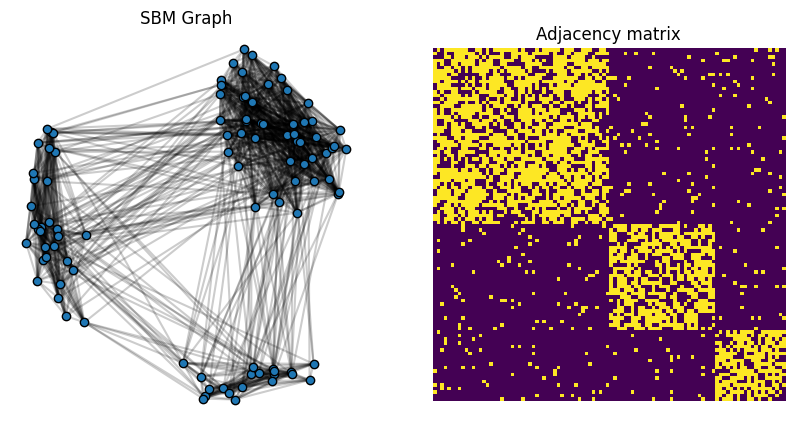

In [2]:
rng = np.random.RandomState(42)

def get_sbm(n, nc, ratio, P):
    nbpc = np.round(n * ratio).astype(int)
    n = np.sum(nbpc)
    C = np.zeros((n, n))
    for c1 in range(nc):
        for c2 in range(c1 + 1):
            if c1 == c2:
                for i in range(np.sum(nbpc[:c1]), np.sum(nbpc[: c1 + 1])):
                    for j in range(np.sum(nbpc[:c2]), i):
                        if rng.rand() <= P[c1, c2]:
                            C[i, j] = 1
            else:
                for i in range(np.sum(nbpc[:c1]), np.sum(nbpc[: c1 + 1])):
                    for j in range(np.sum(nbpc[:c2]), np.sum(nbpc[: c2 + 1])):
                        if rng.rand() <= P[c1, c2]:
                            C[i, j] = 1
    return C + C.T

n = 100
nc = 3
ratio = np.array([0.5, 0.3, 0.2])
P = np.array(0.6 * np.eye(3) + 0.05 * np.ones((3, 3)))
C1 = get_sbm(n, nc, ratio, P)

# get 2d position for nodes
x1 = MDS(dissimilarity="precomputed", random_state=0).fit_transform(1 - C1)

def plot_graph(x, C, color="C0", s=None):
    for j in range(C.shape[0]):
        for i in range(j):
            if C[i, j] > 0:
                pl.plot([x[i, 0], x[j, 0]], [x[i, 1], x[j, 1]], alpha=0.2, color="k")
    pl.scatter(
        x[:, 0], x[:, 1], c=color, s=s, zorder=10, edgecolors="k", cmap="tab10", vmax=9
    )

pl.figure(1, (10, 5))
pl.clf()
pl.subplot(1, 2, 1)
plot_graph(x1, C1, color="C0")
pl.title("SBM Graph")
pl.axis("off")
pl.subplot(1, 2, 2)
pl.imshow(C1, interpolation="nearest")
pl.title("Adjacency matrix")
pl.axis("off")

## Optimizing GW w.r.t the weights on a template structure

000 | 0.2650297103818839
001 | 0.26287801812765815
002 | 0.2606092780542172
003 | 0.2584645701500988
004 | 0.2556115805612028
005 | 0.25338142163603006
006 | 0.2506203992822609
007 | 0.24795521568500217
008 | 0.24478090152030318
009 | 0.24195446882098204
010 | 0.23995859351509308
011 | 0.23937756820076497
012 | 0.2367552120372375
013 | 0.23676363256346986
014 | 0.23448317152950748
015 | 0.23387038916603664
016 | 0.2322754308314479
017 | 0.23062612411125857
018 | 0.2296592912100529
019 | 0.22735724287930317
020 | 0.22727900415695337
021 | 0.22435128963048095
022 | 0.22475557075117575
023 | 0.22216095782770268
024 | 0.22158005455371915
025 | 0.2197362971061698
026 | 0.2185109038949887
027 | 0.21705276097042267
028 | 0.2152819537155631
029 | 0.2132114625388347
030 | 0.2120622026150946
031 | 0.21005066795579752
032 | 0.20741973974668398
033 | 0.20592712388443166
034 | 0.2045650418492546
035 | 0.20222464441838336
036 | 0.2021095322246544
037 | 0.19960458218059846
038 | 0.19890049185215178
0

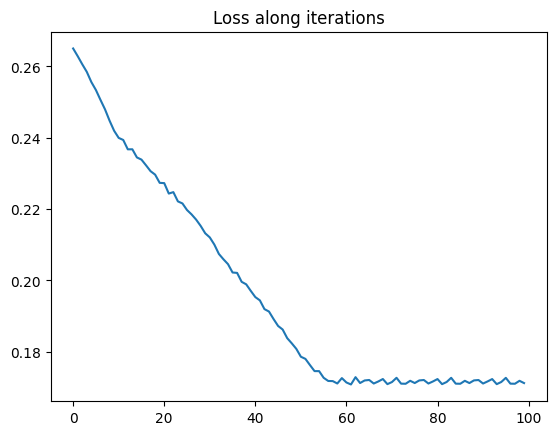

In [3]:
C0 = np.eye(3)

def min_weight_gw(C1, C2, a2, nb_iter_max=100, lr=1e-2):
    """solve min_a GW(C1, C2, a, a2) by gradient descent"""
    C1_torch = torch.tensor(C1)
    C2_torch = torch.tensor(C2)

    a0 = rng.rand(C1.shape[0]) # random init
    a0 /= a0.sum() # on simplex
    a1_torch = torch.tensor(a0).requires_grad_(True)
    a2_torch = torch.tensor(a2)

    loss_iter = []

    for i in range(nb_iter_max):
        loss = gromov_wasserstein2(C1_torch, C2_torch, a1_torch, a2_torch)
        loss_iter.append(loss.clone().detach().cpu().numpy())
        loss.backward()
        print("{:03d} | {}".format(i, loss_iter[-1]))

        # performs a step of projected gradient descent
        with torch.no_grad():
            grad = a1_torch.grad
            a1_torch -= grad * lr # step
            a1_torch.grad.zero_()
            a1_torch.data = ot.utils.proj_simplex(a1_torch)

    a1 = a1_torch.clone().detach().cpu().numpy()

    return a1, loss_iter


a0_est, loss_iter0 = min_weight_gw(C0, C1, ot.unif(n), nb_iter_max=100, lr=1e-2)
pl.figure(2)
pl.plot(loss_iter0)
pl.title("Loss along iterations")

print("Estimated weights: ", a0_est)
print("True proportions: ", ratio)

## Community clustering with uniform and estimated weights

In [ ]:
T_unif = ot.gromov_wasserstein(C1, C0, ot.unif(n), ot.unif(3))
label_unif = T_unif.argmax(1)

T_est = ot.gromov_wasserstein(C1, C0, ot.unif(n), a0_est)
label_est = T_est.argmax(1)

pl.figure(3, (10, 5))
pl.clf()
pl.subplot(1, 2, 1)
plot_graph(x1, C1, color=label_unif)
pl.title("Graph clustering unif, weights")
